## Contents:

>>[Contents:](#scrollTo=Hvrj6bheKFs-)

>>[EDA](#scrollTo=-08w5ZlTKB6h)

>>>[Distribution and skewness:](#scrollTo=sbNZNMLcJjib)

>>[2- Data prepration](#scrollTo=tceFCR1AK6Wj)

>>>[1- Encoding:](#scrollTo=9IYToMk0LlbM)

>>>[2- Correlation:](#scrollTo=7gAcC1fnJbTL)

>>>[3- Replace Outliers with medians](#scrollTo=EeycHJoQ6ZYv)

>>>[4- Splitting](#scrollTo=mL2sjQC6Bf42)

>>>[5- Scaling](#scrollTo=ONhglnpAAT31)

>>[Modeling](#scrollTo=R23appKPCgp1)

>>[Evaluation](#scrollTo=5VwBXxBFz6uQ)



## EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('data.csv')
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [ ]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [ ]:
df.duplicated().sum()

0

In [ ]:
df.isna().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

### Distribution and skewness:

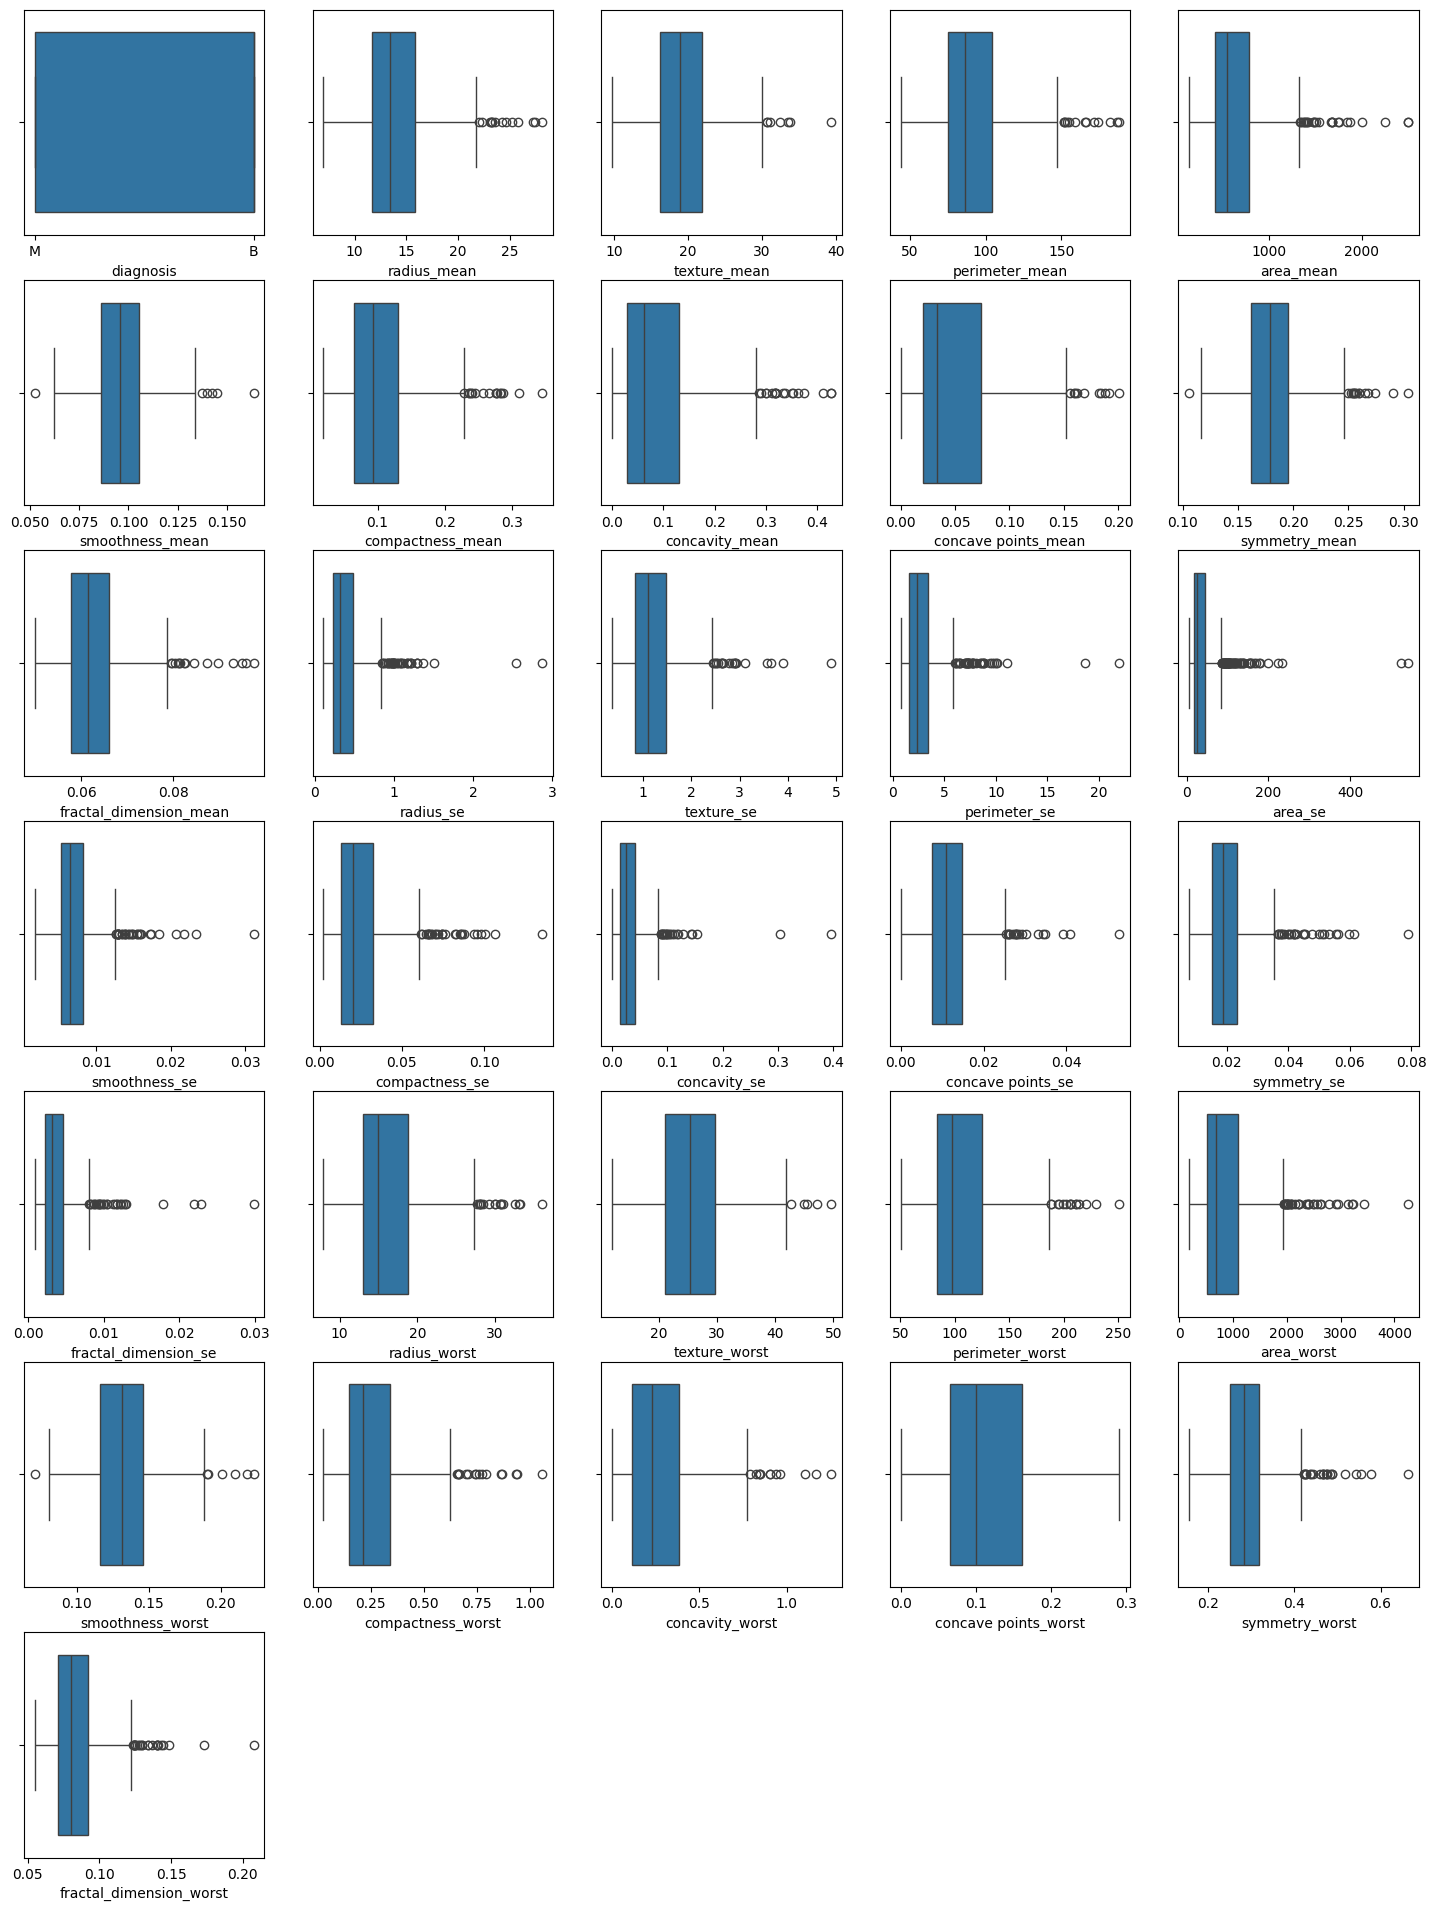

In [ ]:
plt.figure(figsize=(18,24))
for i,col in enumerate(df.columns):
  plt.subplot(7,5,i+1),
  sns.boxplot(x=col,data=df),
  #plt.title(i),
plt.show()




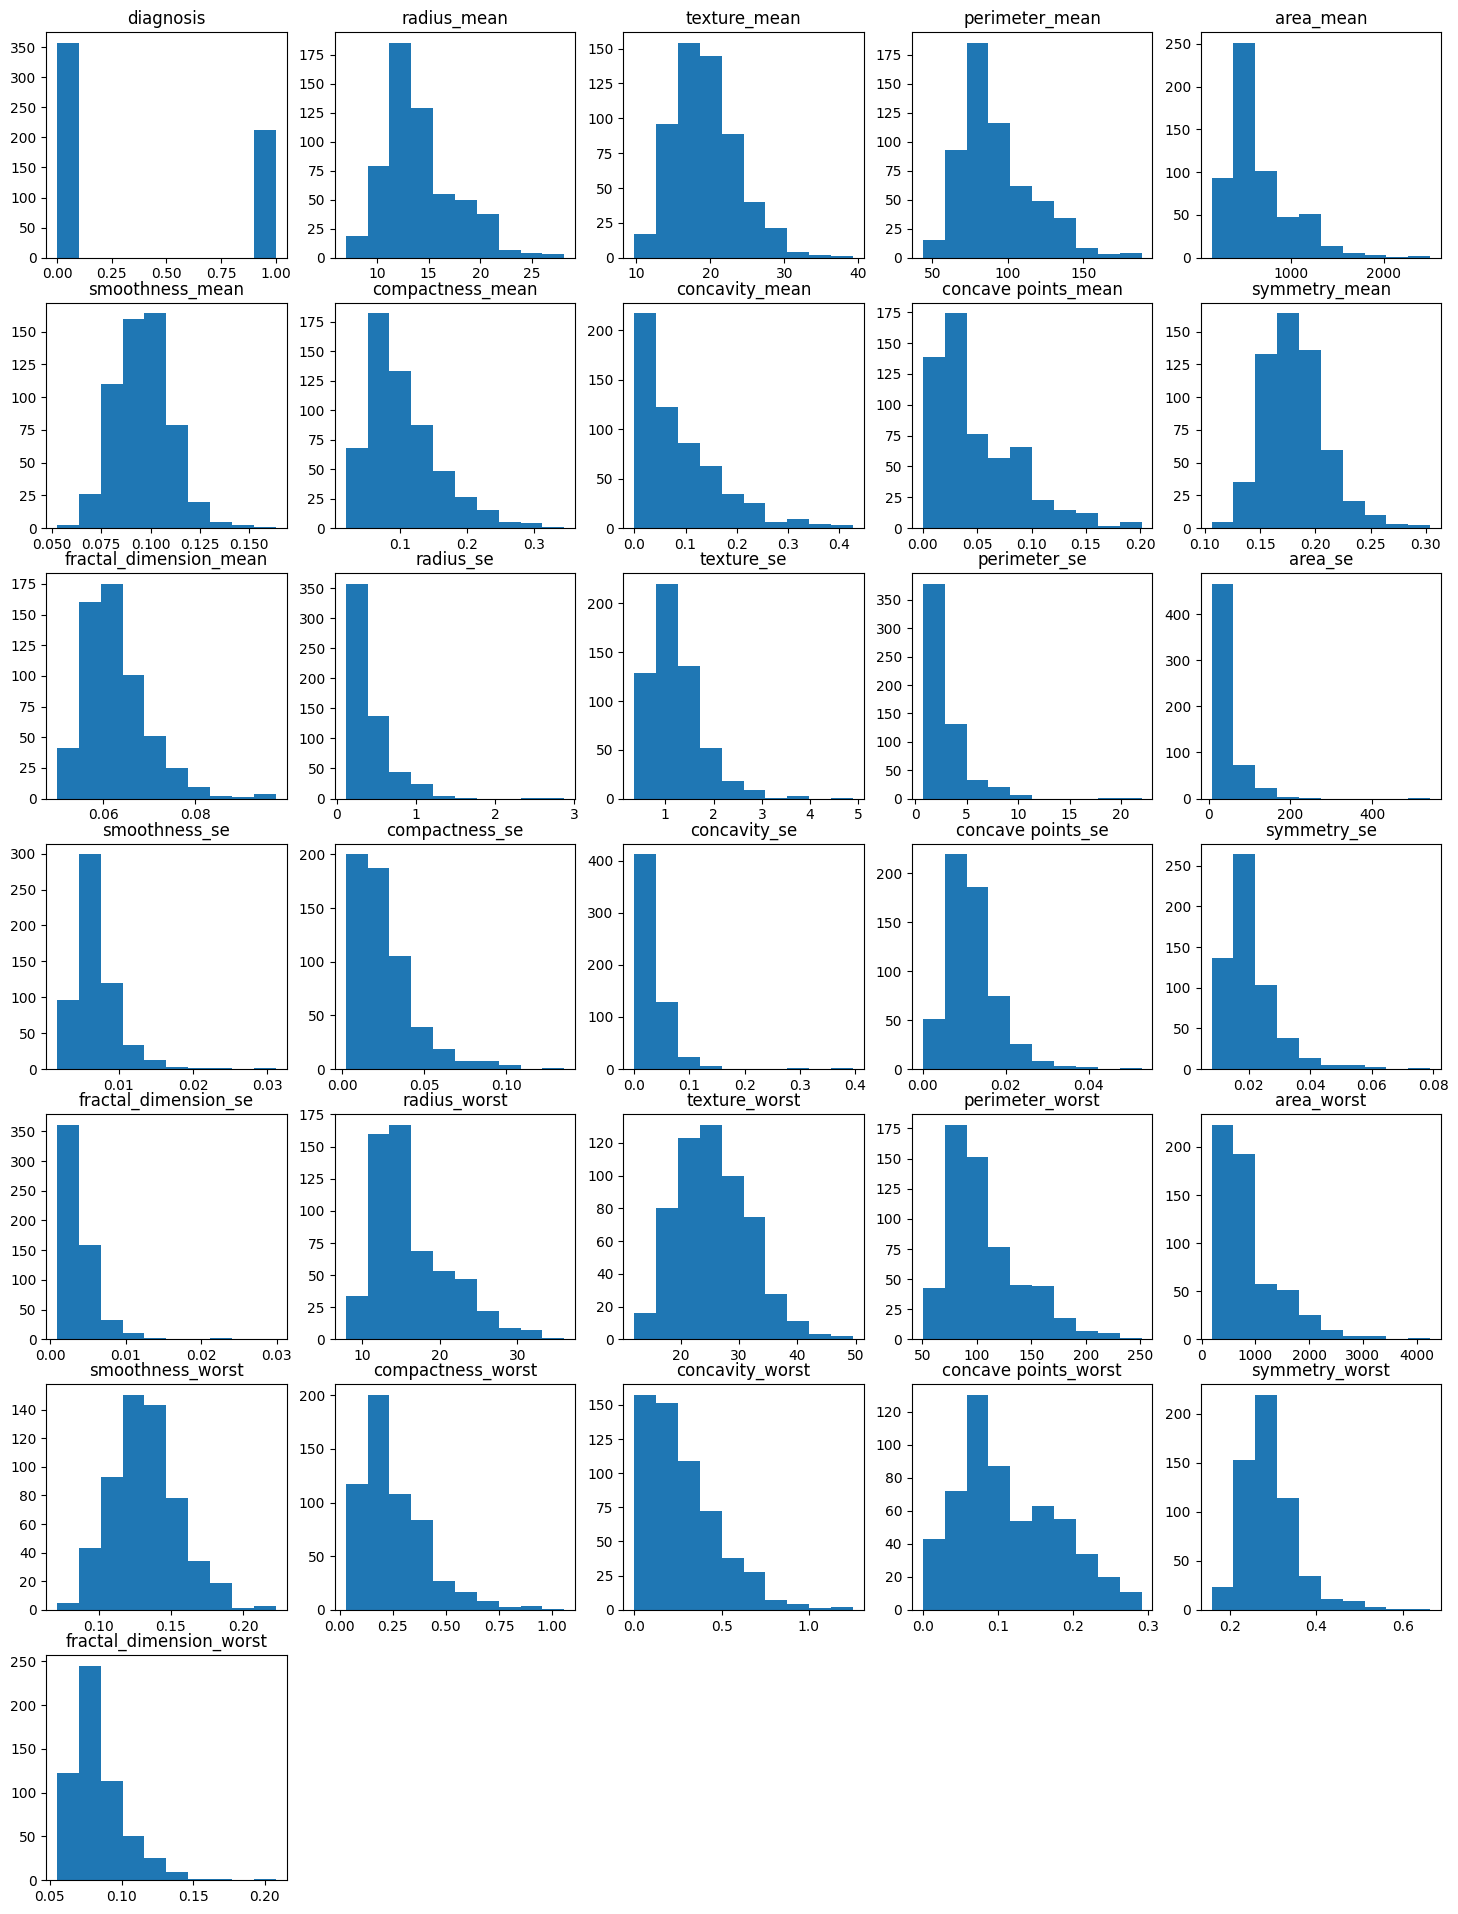

In [ ]:
plt.figure(figsize=(18,24))
for i,col in enumerate(df.columns):
  plt.subplot(7,5, i+1),
  plt.hist(df[col]),
  plt.title(col),
plt.show()


## 2- Data prepration

In [ ]:
df.drop(columns='id',inplace=True)

In [ ]:
df.drop(columns='Unnamed: 32',inplace=True)

### 1- Encoding:

In [ ]:

df['diagnosis']= df['diagnosis'].replace({'M':1,'B':0})

### 2- Correlation:

<Axes: >

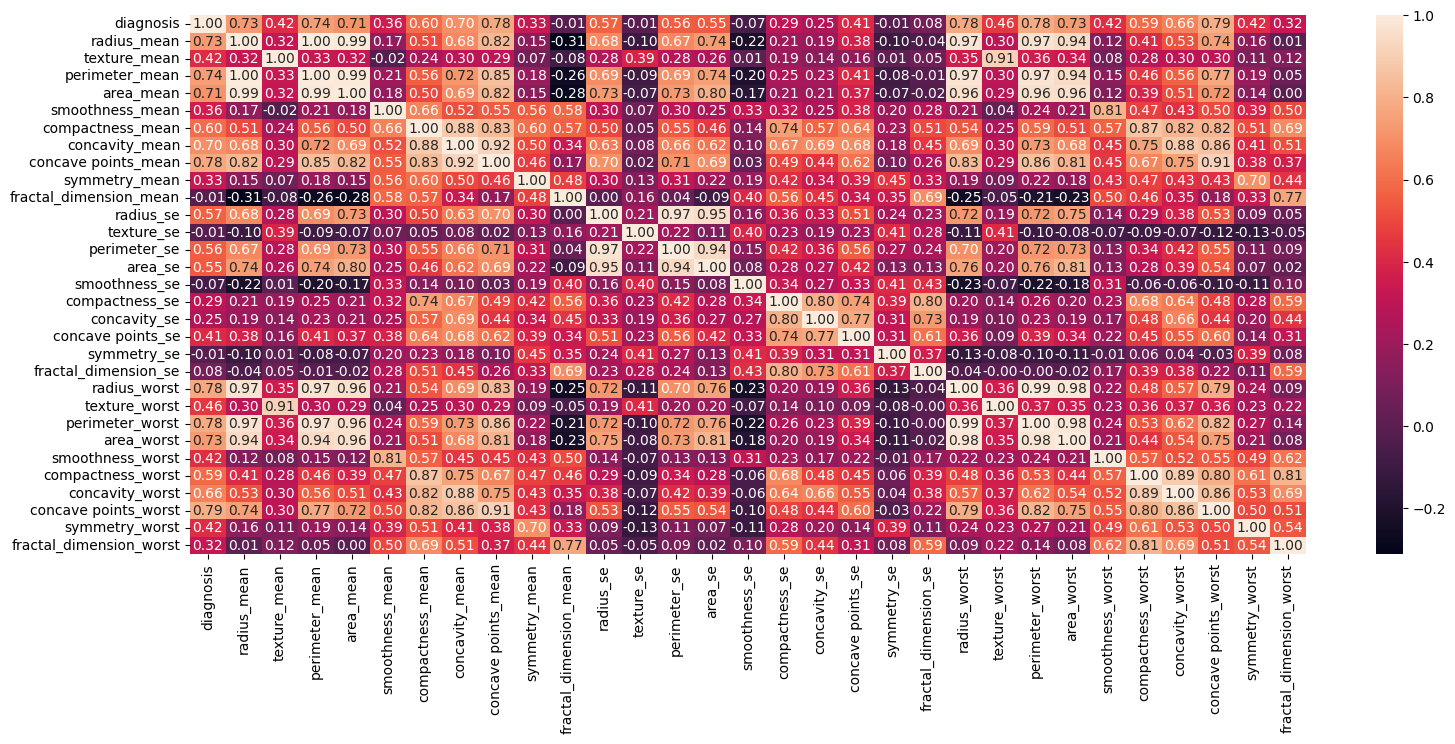

In [ ]:
plt.figure(figsize=(18,7))
corr = df.corr()
sns.heatmap(corr, annot=True,fmt='.2f')

In [ ]:
corre=df.corr()['diagnosis'] > 0.55
pd.DataFrame(corre).T

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,True,True,False,True,True,False,True,True,True,False,...,True,False,True,True,False,True,True,True,False,False


In [ ]:
corre[corre==True].index

Index(['diagnosis', 'radius_mean', 'perimeter_mean', 'area_mean',
       'compactness_mean', 'concavity_mean', 'concave points_mean',
       'radius_se', 'perimeter_se', 'radius_worst', 'perimeter_worst',
       'area_worst', 'compactness_worst', 'concavity_worst',
       'concave points_worst'],
      dtype='object')

In [ ]:
cm_corr= df.corr()['diagnosis']
cm_corr[cm_corr > .55]

diagnosis               1.000000
radius_mean             0.730029
perimeter_mean          0.742636
area_mean               0.708984
compactness_mean        0.596534
concavity_mean          0.696360
concave points_mean     0.776614
radius_se               0.567134
perimeter_se            0.556141
radius_worst            0.776454
perimeter_worst         0.782914
area_worst              0.733825
compactness_worst       0.590998
concavity_worst         0.659610
concave points_worst    0.793566
Name: diagnosis, dtype: float64

In [ ]:
corro= df.corr()['diagnosis'] > 0.55
corro

diagnosis                   True
radius_mean                 True
texture_mean               False
perimeter_mean              True
area_mean                   True
smoothness_mean            False
compactness_mean            True
concavity_mean              True
concave points_mean         True
symmetry_mean              False
fractal_dimension_mean     False
radius_se                   True
texture_se                 False
perimeter_se                True
area_se                    False
smoothness_se              False
compactness_se             False
concavity_se               False
concave points_se          False
symmetry_se                False
fractal_dimension_se       False
radius_worst                True
texture_worst              False
perimeter_worst             True
area_worst                  True
smoothness_worst           False
compactness_worst           True
concavity_worst             True
concave points_worst        True
symmetry_worst             False
fractal_di

###  3- Replace Outliers with medians

In [ ]:
def calculate_quartiles(data):
  data=sorted(data)

  median=np.median(data)
  lower_half= [num for num in data if num <= median]
  upper_half= [num for num in data if num > median]

  Q1= np.median(lower_half)
  Q3=np.median(upper_half)

  return Q1, median, Q3


In [ ]:
X=df.drop(columns=['diagnosis'])
y= df.diagnosis

In [ ]:
for col in df.columns:
  data = df[col].values
  Q1, median, Q3 = calculate_quartiles(data)

  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5  * IQR
  upper_bound = Q3 + 1.5 * IQR
  # replace outleirs with median

  df[col]=np.where(
      (df[col] < lower_bound) | (df[col] > upper_bound),
      median,df[col]
  )



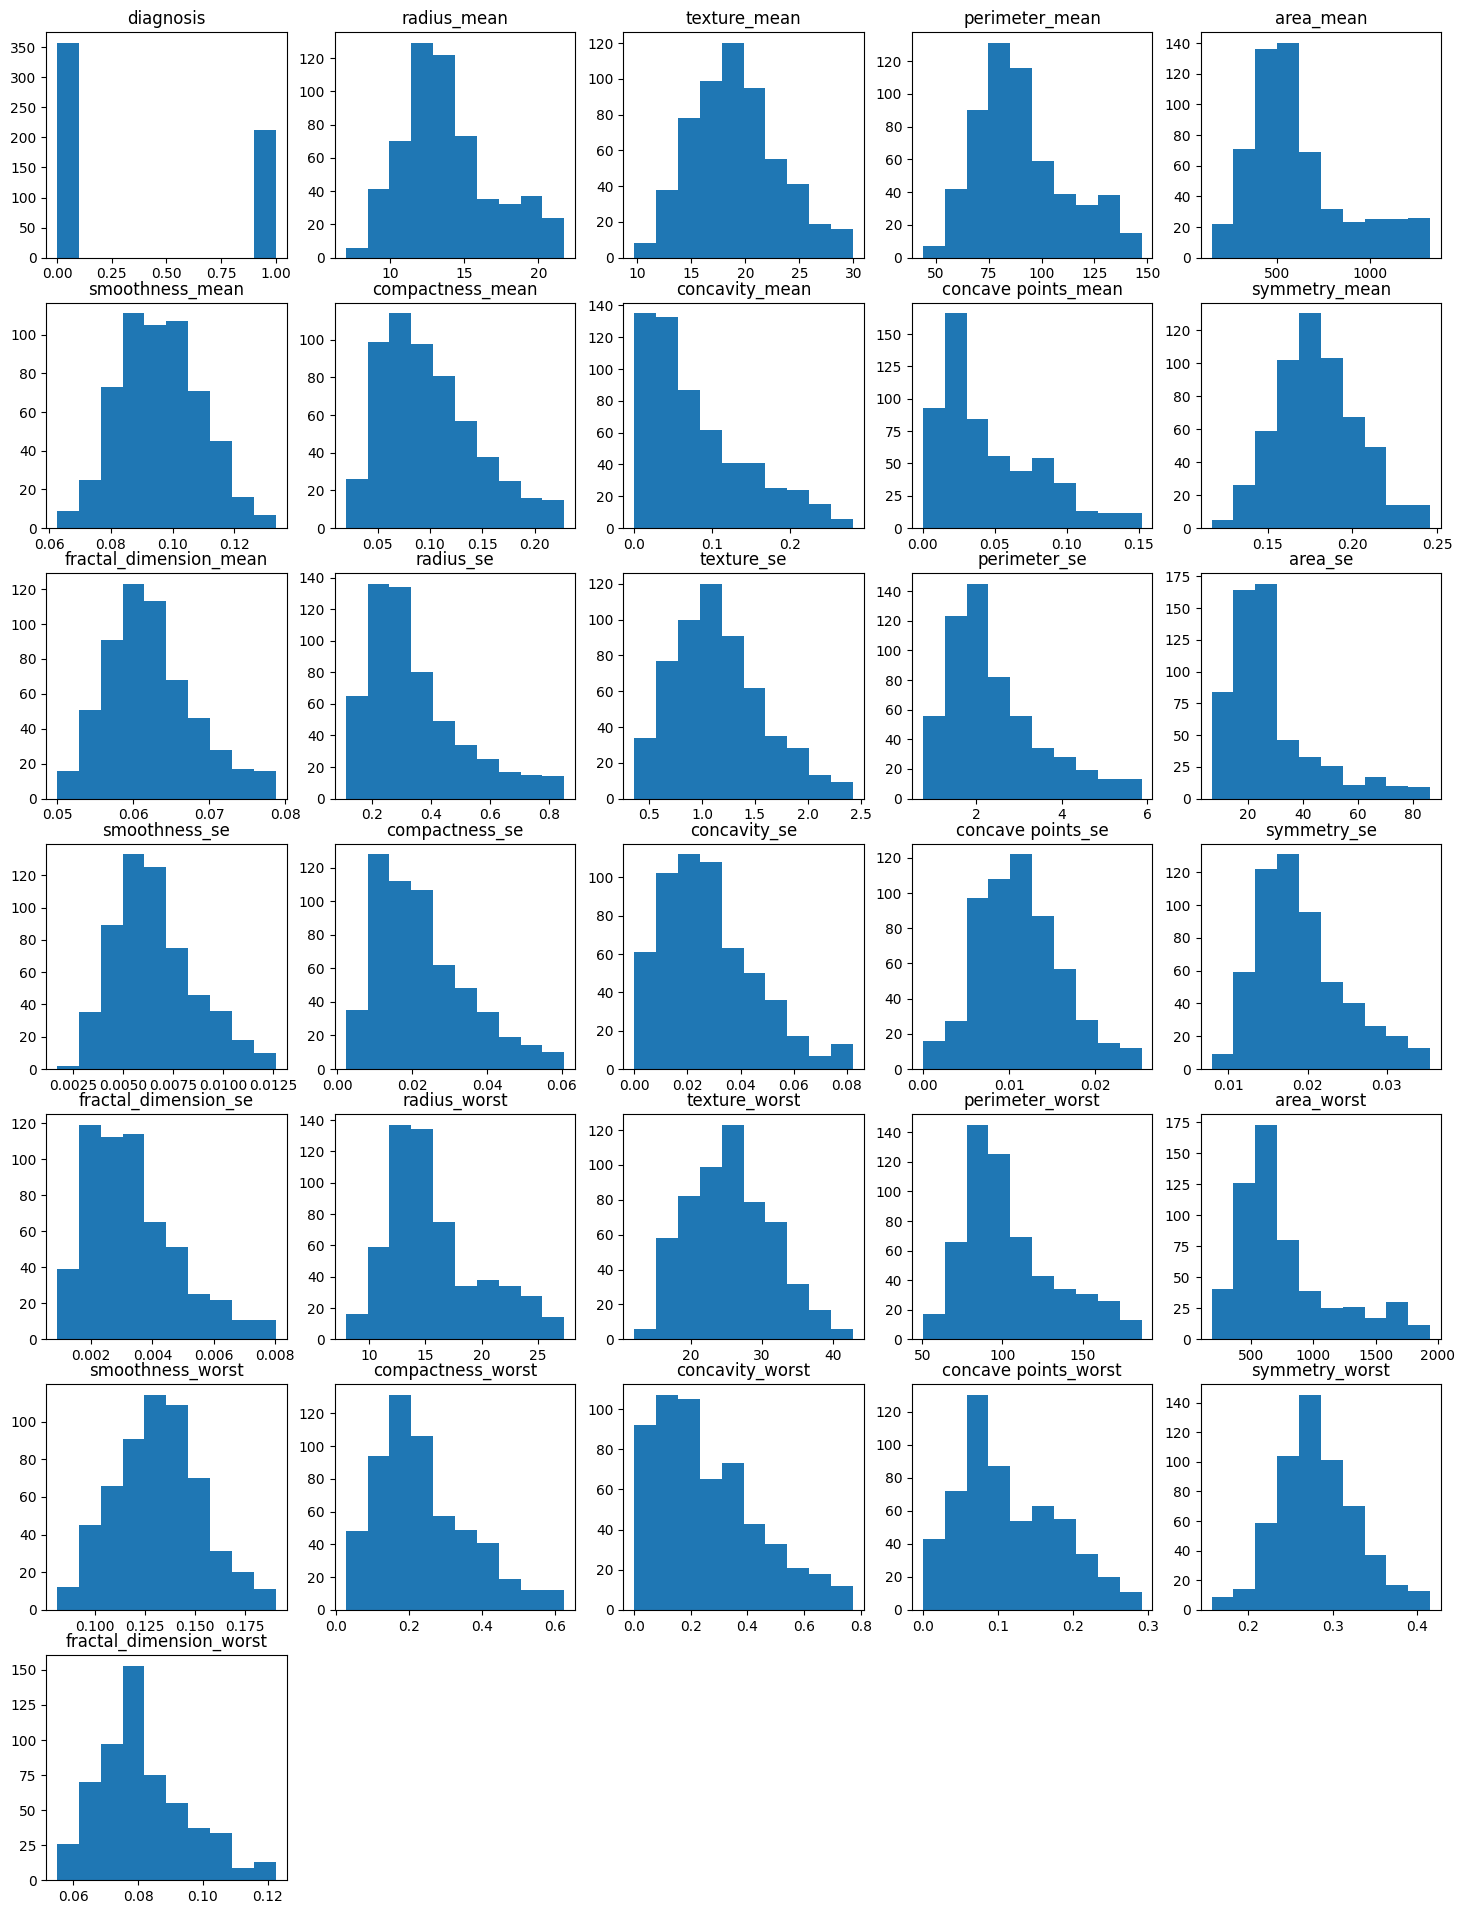

In [ ]:
plt.figure(figsize=(18,24))
for i,col in enumerate(df.columns):
  plt.subplot(7,5, i+1),
  plt.hist(df[col]),
  plt.title(col),
plt.show()

### 4- Splitting

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,train_size=0.33, stratify=y)
X_train.shape

(187, 30)

### 5- Scaling

In [ ]:
from sklearn.preprocessing import RobustScaler

In [ ]:
scaler = RobustScaler()
X_train=scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

## Modeling

In [ ]:
from sklearn.svm import SVC

svc_model= SVC()

svc_model.fit(X_train, y_train)

svc_pred= svc_model.predict(X_test)

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C':[.5, 1,1.5,2,2.5],
    'kernel':['rbf','poly','sigmoid'],
    'gamma':['scale','auto']
}
grid_search = GridSearchCV(svc_model,param_grid,cv=5)

grid_search.fit(X_train,y_train)

grid_pred= grid_search.predict(X_test)

In [ ]:
grid_search.best_params_

{'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}

## Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix , accuracy_score


In [ ]:
confusion_matrix(y_test,svc_pred)

array([[233,   7],
       [  6, 136]])

In [ ]:
accuracy_score(y_test, svc_pred)

0.9659685863874345

Text(0.5, 1.0, 'GridSearch SVC')

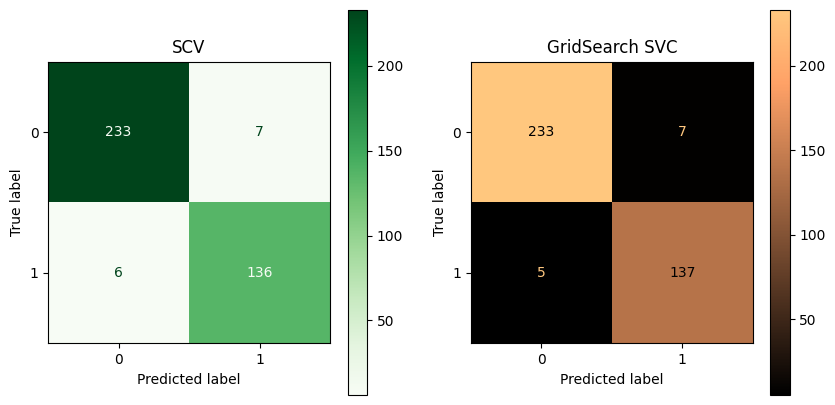

In [ ]:
from sklearn.metrics import precision_score, recall_score, ConfusionMatrixDisplay, classification_report


fig ,axes =  plt.subplots(nrows = 1, ncols=2 ,figsize=(10,5))

cm_svc= confusion_matrix(y_test, svc_pred)
svc_display = ConfusionMatrixDisplay(cm_svc).plot(ax=axes[0],cmap='Greens')
axes[0].set_title('SCV')

cm_grid = confusion_matrix(y_test, grid_pred)
grid_display = ConfusionMatrixDisplay(cm_grid).plot(ax=axes[1],cmap='copper')
axes[1].set_title('GridSearch SVC')


In [ ]:
accuracy_score(y_test,grid_pred)

0.9685863874345549

In [ ]:
print(f'SVC recall score:  {recall_score(y_test,svc_pred)}\nGridSearch SVC recall score: {recall_score(y_test, grid_pred)}')



SVC recall score:  0.9577464788732394
GridSearch SVC recall score: 0.9647887323943662


In [ ]:
print(f' SVC precesion score: {precision_score(y_test, svc_pred)}\n GridSearch SVC precision score: {precision_score(y_test,grid_pred)}')

 SVC precesion score: 0.951048951048951
 GridSearch SVC precision score: 0.9513888888888888


In [ ]:
print(classification_report(y_test, svc_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       240
           1       0.95      0.96      0.95       142

    accuracy                           0.97       382
   macro avg       0.96      0.96      0.96       382
weighted avg       0.97      0.97      0.97       382



In [ ]:
print(classification_report(y_test, grid_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       240
           1       0.95      0.96      0.96       142

    accuracy                           0.97       382
   macro avg       0.97      0.97      0.97       382
weighted avg       0.97      0.97      0.97       382

